## Purchase Behavior EDA (Professional Version)
Goal: Evaluate how purchase behavior relates to churn using consistent visual, statistical, and effect-size evidence.

### Scope
- Total_Purchases
- Average_Order_Value
- Days_Since_Last_Purchase
- Discount_Usage_Rate

### Workflow
1. Standardized 3-view chart per feature
2. Mann-Whitney U test + rank-biserial effect size
3. Quartile churn trend and feature ranking summary

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import pandas as pd
from scipy import stats

df = pd.read_csv('../../../Data/processed/cleaned_customer_data.csv')

In [7]:
purchase_behavior_features = [
    "Total_Purchases",
    "Average_Order_Value",
    "Days_Since_Last_Purchase",
    "Discount_Usage_Rate",
]

purchase_behavior_data = df[purchase_behavior_features].copy()

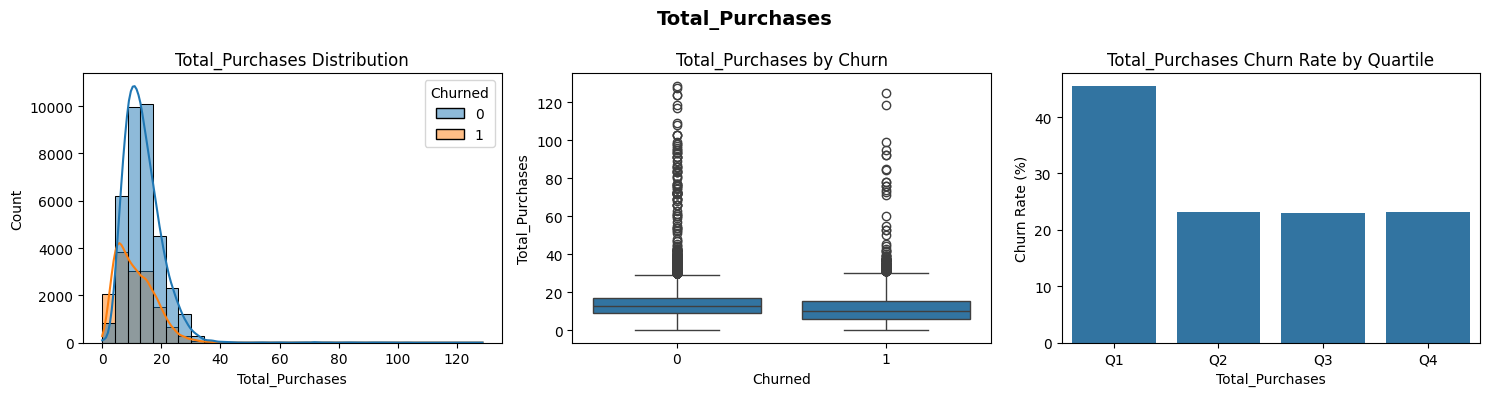

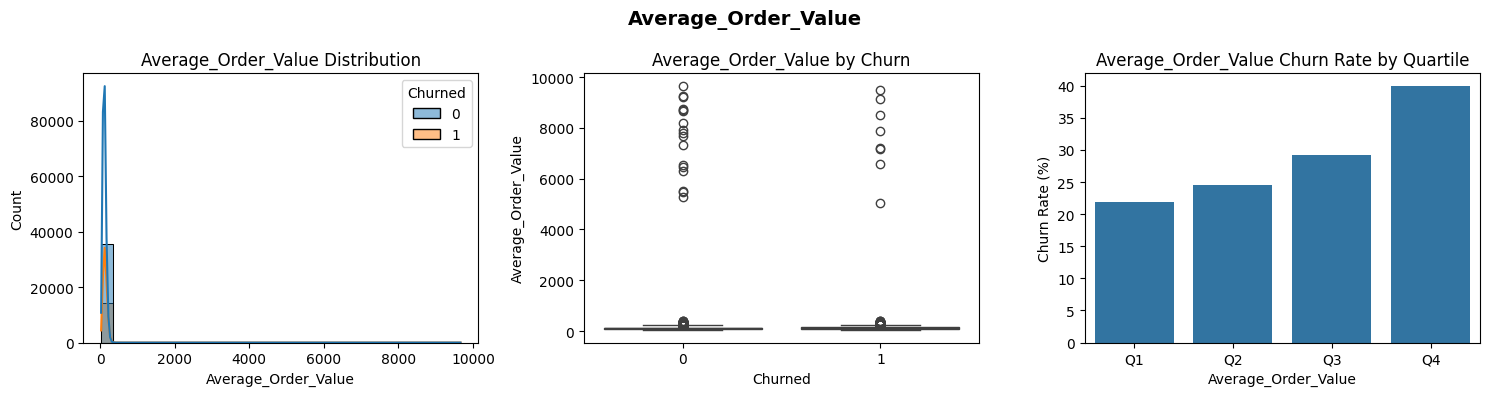

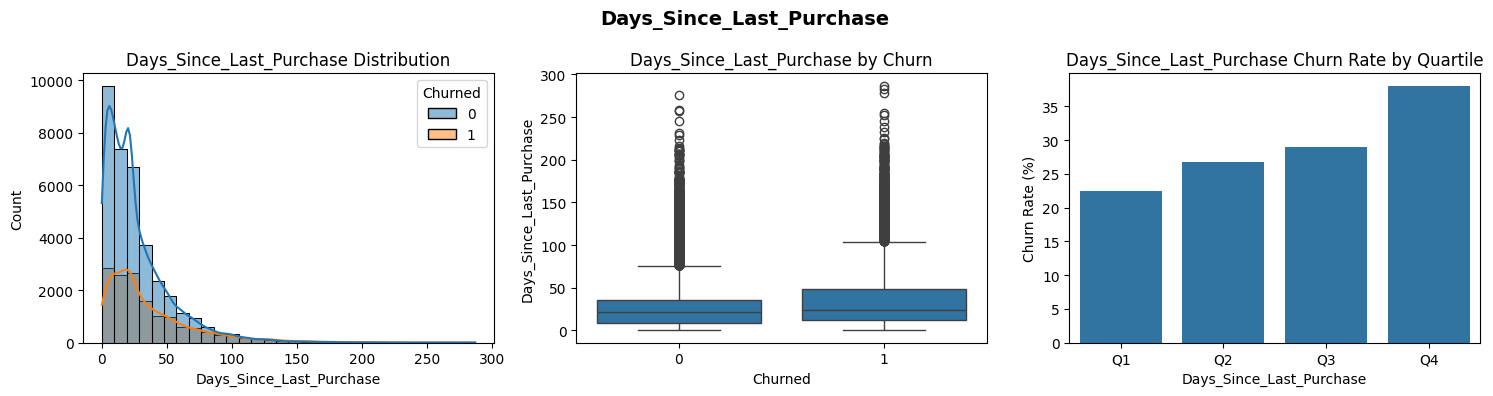

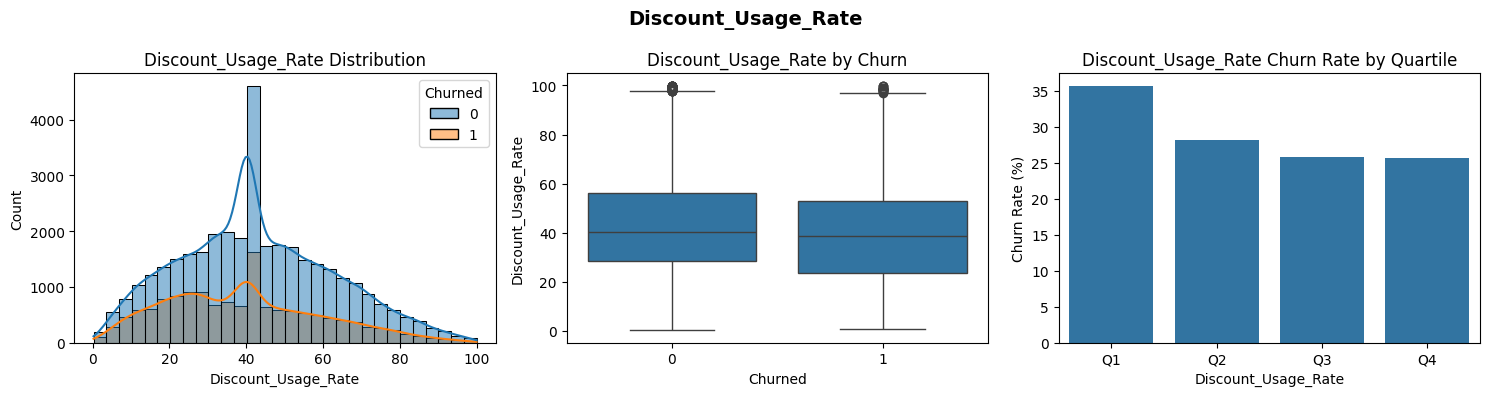

In [8]:
def analyze_feature(feature, df):
    """Analyze one purchase feature in 3 views: distribution, group gap, and churn trend."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    sns.histplot(data=df, x=feature, hue='Churned', bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f'{feature} Distribution')
    
    sns.boxplot(data=df, x='Churned', y=feature, ax=axes[1])
    axes[1].set_title(f'{feature} by Churn')
    
    # qcut keeps bucket sizes balanced for fair churn-rate comparison
    segments = pd.qcut(df[feature], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    churn_rate = df.groupby(segments, observed=True)['Churned'].mean() * 100
    sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=axes[2])
    axes[2].set_title(f'{feature} Churn Rate by Quartile')
    axes[2].set_ylabel('Churn Rate (%)')
    
    plt.suptitle(feature, fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

for feature in purchase_behavior_features:
    analyze_feature(feature, df)

In [9]:
summary_stats = purchase_behavior_data.describe().T
summary_stats['skewness'] = purchase_behavior_data.skew()
summary_stats['kurtosis'] = purchase_behavior_data.kurt()
summary_stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Total_Purchases,50000.0,13.116560,7.005246,0.00,8.00,12.00,17.00,128.700000,2.714766,25.934688
Average_Order_Value,50000.0,123.117330,175.569714,26.38,87.05,112.97,144.44,9666.379178,42.363862,1959.931679
Days_Since_Last_Purchase,50000.0,29.265300,28.866043,0.00,9.00,21.00,39.00,287.000000,2.090718,6.286718
Discount_Usage_Rate,50000.0,41.601659,20.204323,0.24,26.50,40.20,55.20,99.960000,0.335679,-0.417174


In [ ]:
churned = df.loc[df['Churned'] == 1, 'Total_Purchases']
not_churned = df.loc[df['Churned'] == 0, 'Total_Purchases']

u_stat, p_value = stats.mannwhitneyu(
    churned,
    not_churned,
    alternative='two-sided'
)

auc_probability = u_stat / (len(churned) * len(not_churned))
rank_biserial = 2 * auc_probability - 1

print(f'Mann-Whitney U Test: U={u_stat:.1f}, p-value={p_value:.6f}')
print(f'Rank-biserial effect size: {rank_biserial:.3f}')

if p_value < 0.05:
    print('There is a statistically significant difference in Total Purchases between churn and non-churn groups.')
else:
    print('No statistically significant difference in Total Purchases was found between churn and non-churn groups.')

Mann-Whitney U Test: U=195374059.0, p-value=0.000000
มีความแตกต่างอย่างมีนัยสำคัญระหว่างกลุ่ม Churn และ Non-Churn ใน Total Purchases


In [11]:
def rank_biserial_from_u(u_stat, n_churn, n_non_churn):
    auc_probability = u_stat / (n_churn * n_non_churn)
    return 2 * auc_probability - 1

def effect_label(value):
    abs_value = abs(value)
    if abs_value >= 0.5:
        return 'Large'
    if abs_value >= 0.3:
        return 'Medium'
    if abs_value >= 0.1:
        return 'Small'
    return 'Negligible'

summary_rows = []
quartile_tables = {}

for feature in purchase_behavior_features:
    churn = df.loc[df['Churned'] == 1, feature].dropna()
    non_churn = df.loc[df['Churned'] == 0, feature].dropna()

    u_stat, p_value = stats.mannwhitneyu(churn, non_churn, alternative='two-sided')
    rb = rank_biserial_from_u(u_stat, len(churn), len(non_churn))

    bins = pd.qcut(df[feature], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    quartile_df = pd.DataFrame({'quartile': bins, 'Churned': df['Churned']})
    quartile_rate = quartile_df.groupby('quartile', observed=True)['Churned'].mean() * 100
    quartile_tables[feature] = quartile_rate

    summary_rows.append({
        'feature': feature,
        'corr_with_churn': df[feature].corr(df['Churned']),
        'u_stat': u_stat,
        'p_value': p_value,
        'rank_biserial': rb,
        'effect_size_label': effect_label(rb),
        'churn_q1_pct': quartile_rate.iloc[0],
        'churn_q4_pct': quartile_rate.iloc[-1],
        'q4_minus_q1_pct': quartile_rate.iloc[-1] - quartile_rate.iloc[0],
    })

purchase_summary = pd.DataFrame(summary_rows).sort_values('q4_minus_q1_pct', ascending=False).reset_index(drop=True)
purchase_summary

,feature,corr_with_churn,u_stat,p_value,rank_biserial,effect_size_label,churn_q1_pct,churn_q4_pct,q4_minus_q1_pct
0,Average_Order_Value,0.042288,306492320.0,2.241635e-252,0.193279,Small,21.862251,39.942391,18.080140
1,Days_Since_Last_Purchase,0.148015,299266859.5,5.846009e-185,0.165148,Small,22.423376,37.992918,15.569542
2,Discount_Usage_Rate,-0.075682,230497443.5,1.474219e-72,-0.102595,Small,35.603765,25.692493,-9.911272
3,Total_Purchases,-0.160393,195374059.0,0.000000e+00,-0.239342,Small,45.484121,23.164867,-22.319254


In [12]:
display_cols = [
    'feature', 'corr_with_churn', 'p_value', 'rank_biserial',
    'effect_size_label', 'churn_q1_pct', 'churn_q4_pct', 'q4_minus_q1_pct'
]

display_df = purchase_summary.copy()
display_df['corr_with_churn'] = display_df['corr_with_churn'].round(3)
display_df['p_value'] = display_df['p_value'].map(lambda x: f'{x:.3e}')
display_df['rank_biserial'] = display_df['rank_biserial'].round(3)
display_df['churn_q1_pct'] = display_df['churn_q1_pct'].round(2)
display_df['churn_q4_pct'] = display_df['churn_q4_pct'].round(2)
display_df['q4_minus_q1_pct'] = display_df['q4_minus_q1_pct'].round(2)
display_df[display_cols]

,feature,corr_with_churn,p_value,rank_biserial,effect_size_label,churn_q1_pct,churn_q4_pct,q4_minus_q1_pct
0,Average_Order_Value,0.042,2.242e-252,0.193,Small,21.86,39.94,18.08
1,Days_Since_Last_Purchase,0.148,5.846e-185,0.165,Small,22.42,37.99,15.57
2,Discount_Usage_Rate,-0.076,1.474e-72,-0.103,Small,35.60,25.69,-9.91
3,Total_Purchases,-0.160,0.000e+00,-0.239,Small,45.48,23.16,-22.32


In [13]:
purchase_summary.to_csv('../../../Data/processed/purchase_behavior_professional_summary.csv', index=False)
print('Saved: Data/processed/purchase_behavior_professional_summary.csv')

Saved: Data/processed/purchase_behavior_professional_summary.csv


In [14]:
insight_lines = []

for _, row in purchase_summary.iterrows():
    direction = 'higher' if row['q4_minus_q1_pct'] > 0 else 'lower'
    insight_lines.append(
        f"- {row['feature']}: Q4 churn is {abs(row['q4_minus_q1_pct']):.2f}pp {direction} than Q1, "
        f"effect={row['effect_size_label']} (rb={row['rank_biserial']:.3f}), p={row['p_value']:.2e}"
    )

print('Executive Insight: Purchase Behavior vs Churn')
print('------------------------------------------------')
for line in insight_lines:
    print(line)

Executive Insight: Purchase Behavior vs Churn
------------------------------------------------
- Average_Order_Value: Q4 churn is 18.08pp higher than Q1, effect=Small (rb=0.193), p=2.24e-252
- Days_Since_Last_Purchase: Q4 churn is 15.57pp higher than Q1, effect=Small (rb=0.165), p=5.85e-185
- Discount_Usage_Rate: Q4 churn is 9.91pp lower than Q1, effect=Small (rb=-0.103), p=1.47e-72
- Total_Purchases: Q4 churn is 22.32pp lower than Q1, effect=Small (rb=-0.239), p=0.00e+00


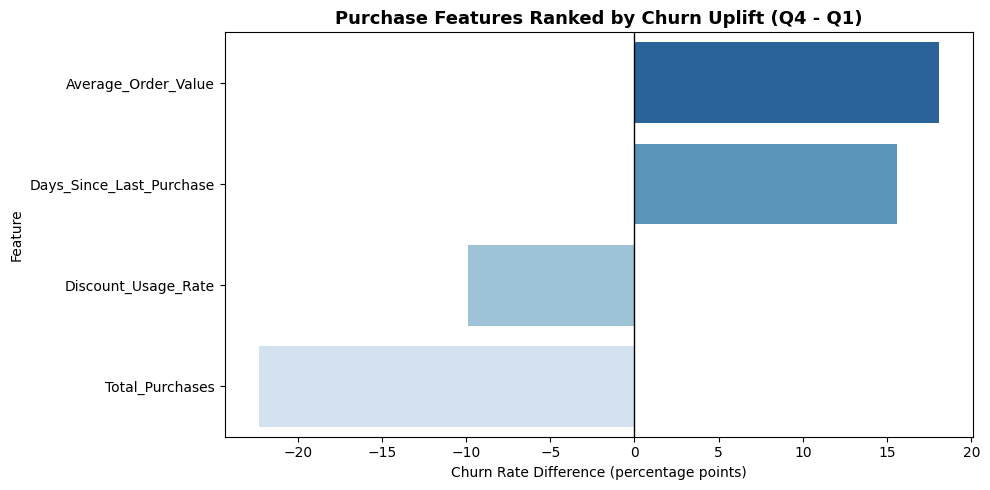

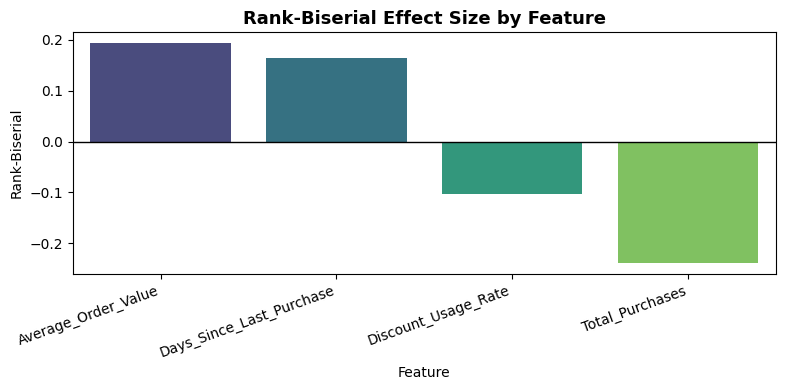

In [16]:
plot_df = purchase_summary.copy()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x='q4_minus_q1_pct',
    y='feature',
    hue='feature',
    palette='Blues_r',
    legend=False
 )
plt.axvline(0, color='black', linewidth=1)
plt.title('Purchase Features Ranked by Churn Uplift (Q4 - Q1)', fontsize=13, weight='bold')
plt.xlabel('Churn Rate Difference (percentage points)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
effect_df = plot_df.sort_values('rank_biserial', ascending=False)
sns.barplot(
    data=effect_df,
    x='feature',
    y='rank_biserial',
    hue='feature',
    palette='viridis',
    legend=False
 )
plt.axhline(0, color='black', linewidth=1)
plt.title('Rank-Biserial Effect Size by Feature', fontsize=13, weight='bold')
plt.xlabel('Feature')
plt.ylabel('Rank-Biserial')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### Consolidated View
This section ranks purchase features by practical churn impact and visualizes both trend strength and statistical evidence.